In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv("housing.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [4]:
df.duplicated().values.any()

False

In [5]:
# plt.figure(figsize=(20,10))
df["total_rooms"].corr(df["total_bedrooms"])

0.9303795046865075

In [6]:
df["avg_rooms"] = df["total_rooms"] / df["households"]
df["avg_bedrooms"] = df["total_bedrooms"] / df["households"]
 
print(df["avg_rooms"].describe())
print(df["avg_bedrooms"].describe())

count    20640.000000
mean         5.429000
std          2.474173
min          0.846154
25%          4.440716
50%          5.229129
75%          6.052381
max        141.909091
Name: avg_rooms, dtype: float64
count    20433.000000
mean         1.097062
std          0.476104
min          0.333333
25%          1.006029
50%          1.048889
75%          1.099631
max         34.066667
Name: avg_bedrooms, dtype: float64


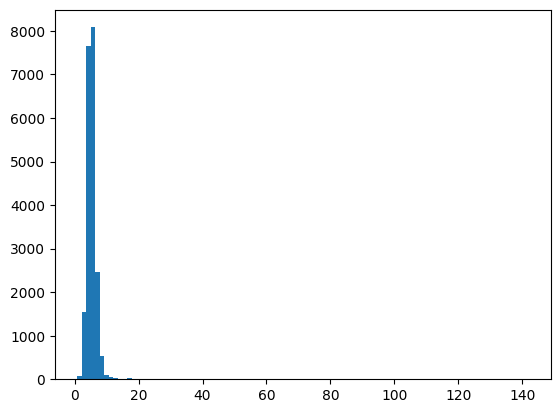

In [7]:
plt.hist(df["avg_rooms"],bins=100);

Text(0.5, 1.0, 'Distribution of Average Rooms')

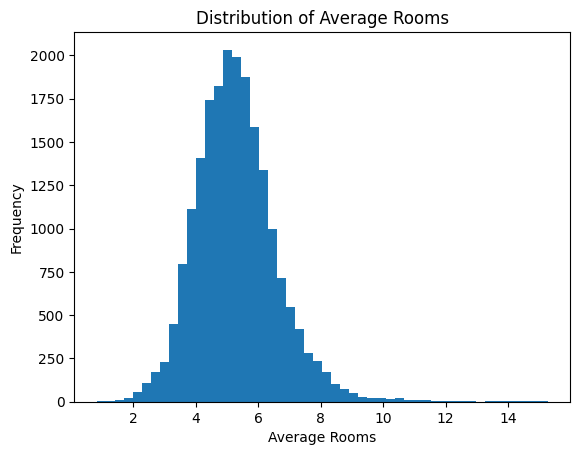

In [8]:
mean_avg_rooms = df["avg_rooms"].mean()
std_avg_rooms = df["avg_rooms"].std()
df = df[df["avg_rooms"] <= mean_avg_rooms + 4 * std_avg_rooms].copy()
plt.hist(df["avg_rooms"], bins=50)
plt.xlabel("Average Rooms")
plt.ylabel("Frequency")
plt.title("Distribution of Average Rooms")

In [9]:
# df.isna().sum()
df.shape

(20535, 12)

/Users/art/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/art/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


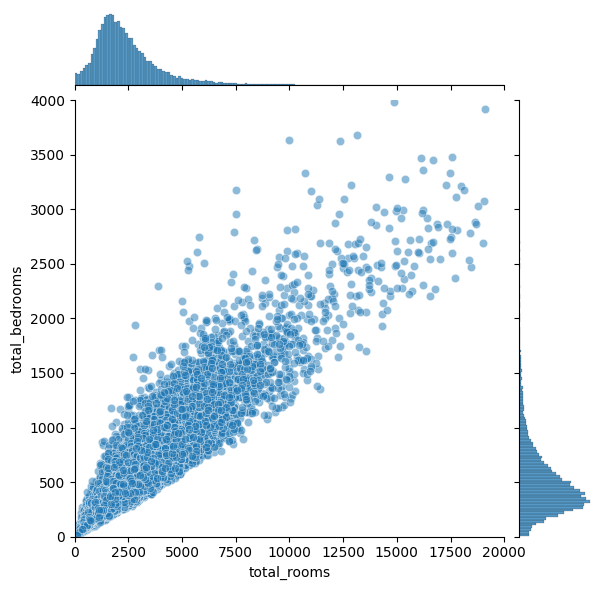

In [10]:
sns.jointplot(x=df["total_rooms"],y=df["total_bedrooms"], alpha=0.5)
plt.xlim(0,20000)
plt.ylim(0,4000)
df.dropna(inplace=True)

<Axes: xlabel='ocean_proximity'>

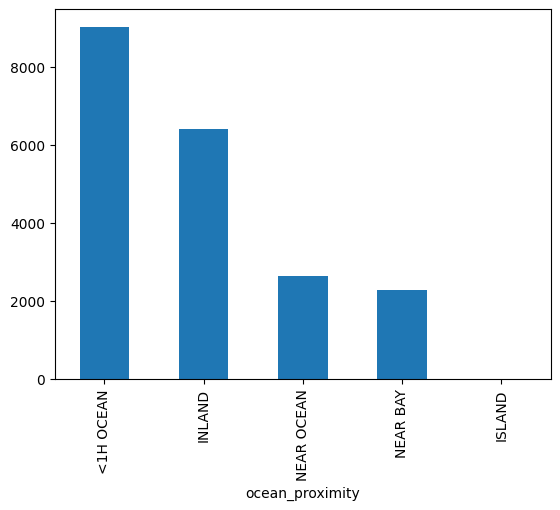

In [11]:
df["ocean_proximity"].value_counts().plot(kind="bar")

In [12]:
le = LabelEncoder()
df["ocean_proximity"] = le.fit_transform(df["ocean_proximity"])

In [13]:
c = df.corr(numeric_only=True)

In [31]:
mask = np.zeros_like(c)
triangle_inicies = np.triu_indices_from(mask)
mask[triangle_inicies] = 1

/Users/art/anaconda3/lib/python3.10/site-packages/seaborn/matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


<Axes: >

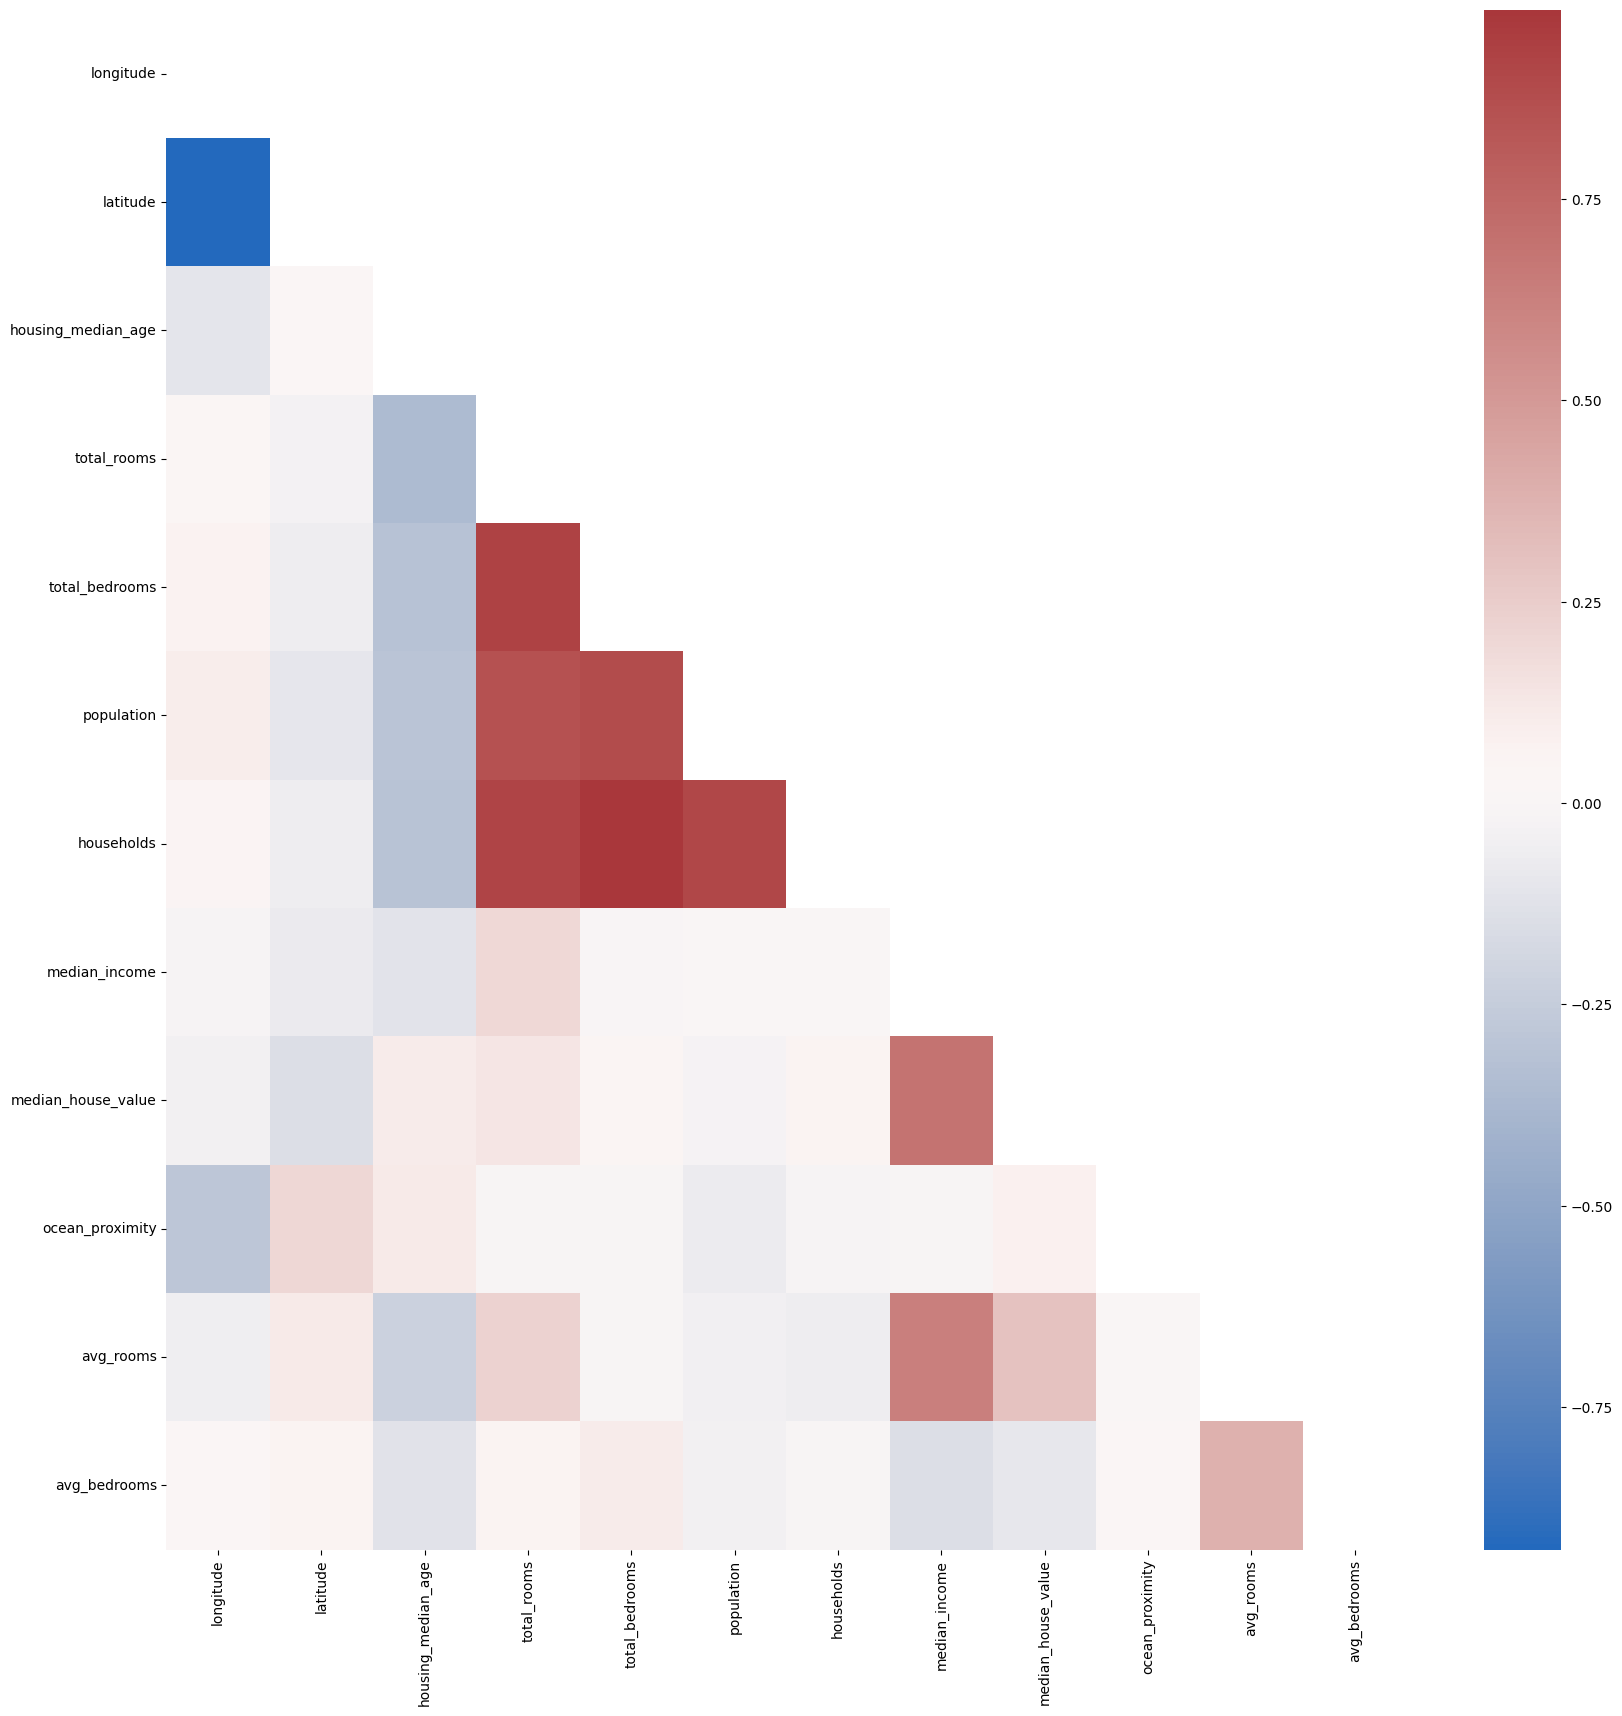

In [32]:
plt.figure(figsize=(20,20))
sns.heatmap(c,annot=True, mask=mask, cmap="vlag")
X = 

In [34]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,avg_rooms,avg_bedrooms
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,3,6.984127,1.023810
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,3,6.238137,0.971880
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,3,8.288136,1.073446
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,3,5.817352,1.073059
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,3,6.281853,1.081081
...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,1,5.045455,1.133333
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,1,6.114035,1.315789
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,1,5.205543,1.120092
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,1,5.329513,1.171920


In [ ]:
ocean_dict = {
    "INLAND": 0,
    "<1H OCEAN": 1,
    "NEAR BAY": 2,
    "NEAR OCEAN": 3,
    "ISLAND": 4
}
 
df['ocean_ranked'] = df['ocean_proximity'].map(ocean_dict)

In [36]:
df["room_bedroom_ratio"] = df["avg_rooms"] / df["avg_bedrooms"]
X = df[["avg_rooms", "room_bedroom_ratio", "latitude", "median_income"]]
y = df["median_house_value"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [37]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [38]:
model.score(X_test,y_test)

0.5125517569523421

<Axes: >

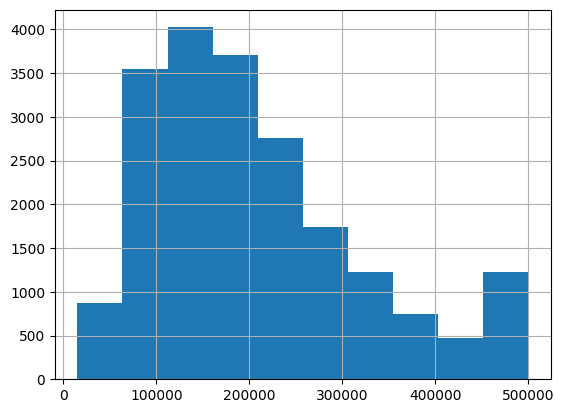

In [39]:
df["median_house_value"].hist()

In [40]:
# df = pd.read_csv("data.csv")
# df_cleaned = drop_missing_values(df)
# df_calculated = calculate_something(df_cleaned)
df_final = df.pipe(drop_missing_values).pipe(calculate_something)

Help on method pipe in module pandas.core.generic:

pipe(func: 'Callable[..., T] | tuple[Callable[..., T], str]', *args, **kwargs) -> 'T' method of pandas.core.frame.DataFrame instance
    Apply chainable functions that expect Series or DataFrames.
    
    Parameters
    ----------
    func : function
        Function to apply to the Series/DataFrame.
        ``args``, and ``kwargs`` are passed into ``func``.
        Alternatively a ``(callable, data_keyword)`` tuple where
        ``data_keyword`` is a string indicating the keyword of
        ``callable`` that expects the Series/DataFrame.
    *args : iterable, optional
        Positional arguments passed into ``func``.
    **kwargs : mapping, optional
        A dictionary of keyword arguments passed into ``func``.
    
    Returns
    -------
    the return type of ``func``.
    
    See Also
    --------
    DataFrame.apply : Apply a function along input axis of DataFrame.
    DataFrame.map : Apply a function elementwise on a whole 